In [3]:
from modules.preprocessing import create_features, get_data, get_preprocessor, split_data
import pandas as pd
import numpy as np

features, target = get_data()
preprocessor = get_preprocessor(features, target)
features = create_features(features)

X_train, X_valid, X_test, y_train, y_valid, y_test = split_data(features, target)
X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)
X_test = preprocessor.transform(X_test)

In [42]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score

model = XGBClassifier(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.01,
    scale_pos_weight=4,
    random_state=42,
    objective='binary:logistic',
    tree_method='approx',
    reg_alpha=0.1,
    reg_lambda=1.0,
)

model.fit(X_train, y_train)
valid_pred = model.predict(X_valid)
valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    
accuracy = accuracy_score(y_valid, valid_pred)
f1 = f1_score(y_valid, valid_pred)
recall = recall_score(y_valid, valid_pred)
precision = precision_score(y_valid, valid_pred)
roc_auc = roc_auc_score(y_valid, valid_pred_proba)

print(f"Validation 성능 - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, ROC AUC: {roc_auc:.4f}")

Validation 성능 - Accuracy: 0.7968, F1 Score: 0.6052, Recall: 0.7565, Precision: 0.5043, ROC AUC: 0.8657


Validation 성능 - Accuracy: 0.7664, F1 Score: 0.5937, Recall: 0.8290, Precision: 0.4624


In [4]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(y_valid, valid_pred)
f1 = f1_score(y_valid, valid_pred)
recall = recall_score(y_valid, valid_pred)
precision = precision_score(y_valid, valid_pred)

print(f"Validation 성능 - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")

Validation 성능 - Accuracy: 0.7659, F1 Score: 0.5931, Recall: 0.8290, Precision: 0.4618


/home/tera/workspace/SKN21-2nd-1Team/ne_eun/.venv/lib/python3.10/site-packages/sklearn/utils/_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


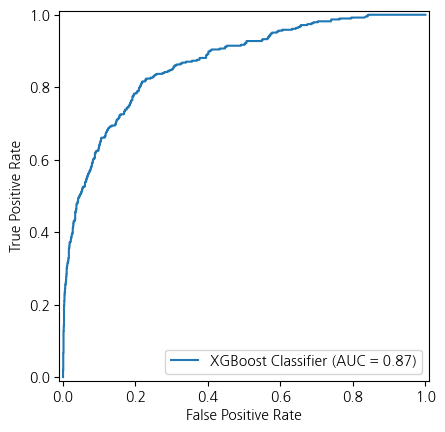

In [5]:

from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score

rfc_roc = roc_auc_score(y_valid, valid_pred_proba)
fpr, recall, thresh = roc_curve(y_valid, valid_pred_proba)
disp_roc_rfc = RocCurveDisplay(
    fpr=fpr, tpr=recall,
    roc_auc=rfc_roc,
    estimator_name='XGBoost Classifier'
)
disp_roc_rfc.plot()
